=== MODEL PERFORMANCE METRICS ===
R² Score (Accuracy): 0.9621
Mean Absolute Error (MAE): 0.6218
Root Mean Squared Error (RMSE): 0.9342



/tmp/ipykernel_1930/3350414721.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


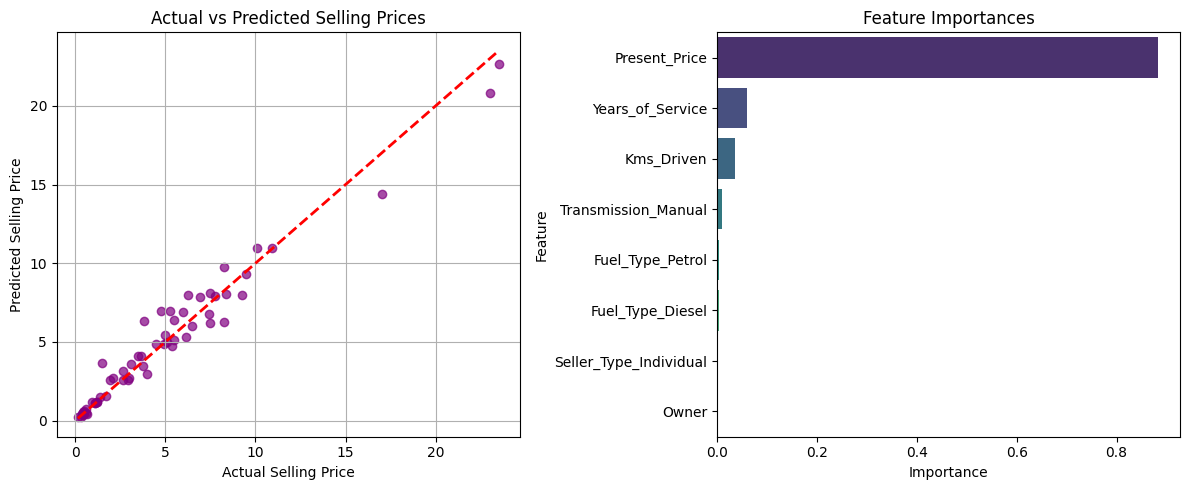

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load the uploaded dataset
df = pd.read_csv('car.csv')

# 2. Feature engineering (calculating age of car)
df['Years_of_Service'] = 2026 - df['Year']
df_clean = df.drop(columns=['Year', 'Car_Name'])

# 3. Separate features (X) and target (y)
X = df_clean.drop(columns=['Selling_Price'])
y = df_clean['Selling_Price']

num_features = ['Present_Price', 'Kms_Driven', 'Owner', 'Years_of_Service']
cat_features = ['Fuel_Type', 'Seller_Type', 'Transmission']

# 4. Build preprocessing & machine learning pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 5. Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_pipeline.fit(X_train, y_train)

# 6. Evaluate metrics
y_pred = model_pipeline.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== MODEL PERFORMANCE METRICS ===")
print(f"R² Score (Accuracy): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}\n")

# 7. Generate performance and feature importance charts
cat_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
ohe_cols = cat_encoder.get_feature_names_out(cat_features)
all_features = num_features + list(ohe_cols)
importances = model_pipeline.named_steps['regressor'].feature_importances_

fi_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Prices')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Feature Importances')

plt.tight_layout()
plt.show()